# Pytorch Machine Learning Tutorial

You know vaguely what machine learning is. You don't know how to do it. Let's fix that.

The fundamental idea of machine learning is using data that we know -- age, sex, race, etc. -- and identifying patterns in that data to make predictions. For example, if Chinese women over 35 are likelier than African-American teenage boys to develop diabetes, a model could use that information to better predict diabetes risk.

A "model" is just an equation. It's a set of instructions for how to transform some input data into a prediction. For example, if we wanted to predict if a number is funny, our instructions might be: 1 / |number - 67|. The farther you get from 67, the less funny the number is, and at 67, it's infinitely funny.

Machine learning involves three steps:
1.  **Guess (Forward Pass):** Make a prediction based on what you currently know.
2.  **Measure (Loss):** Compare your guess to the actual correct answer and quantify how wrong you were.
3.  **Adjust (Backward Pass/Optimize):** Figure out how to change your equation to make a better guess next time.

## NumPy Basics: The Foundation

We're going to train a machine learning model to read handwriting, but we'll build it from the ground up. The first thing we need to understand is **NumPy arrays**. The official description of NumPy is "the fundamental package for scientific computing with Python".

But let's look at what it's actually used for.

Remember, machine learning involves making some equation better. Our equation might process multiple variables before it makes a prediction. For example, in predicting whether someone will get cancer or not, we might process their age AND their sex AND their race, etc.

So having arrays of numbers is useful. Unfortunately, arrays are slow when working on every single element at once. Enter NumPy. It makes arrays faster and more memory-efficient. Generally, in machine learning, we deal with a lot of numbers organized in grids or tables. NumPy arrays provide the perfect structure for this data and the operations we need to perform on them.

In [2]:
# First, install NumPy, since it doesn't come by default with Python
%pip install numpy

  Using cached numpy-2.5.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.5.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Note: you may need to restart the kernel to use updated packages.


Now, we'll start working with numpy. Our first step will just be creating it. 

In [18]:
import numpy as np

# You can create a NumPy array from a Python list
stupid_list = [1, 2, 3, 4, 5]
np_array = np.array(stupid_list)
print("NumPy array:", np_array)

# If we have a table of data, i.e. multiple different records that all keep track of lists of numbers, we can make a 2D array:
stupid_table = [[1, 2, 3], [4, 5, 6]]
np_matrix = np.array(stupid_table)
print("\n2D array (matrix):\n", matrix)

# How can we check whether the array is 1D, 2D, etc.? By checking the `shape` field
print("The array has a dimensionality (shape) of:", np_array.shape)
print("The matrix has a shape of:", np_matrix.shape)

NumPy array: [1 2 3 4 5]

2D array (matrix):
 [[1 2 3]
 [4 5 6]]
The array has a dimensionality (shape) of: (5,)
The matrix has a shape of: (2, 3)


You should see that the array has a shape of (5,). There's only one number because there's only one dimension. And the array has 5 numbers, so that dimension is 5.

The matrix should've had a shape of (2, 3). It had 2 rows of data, and each row had 3 numbers. Becuase its shape has 2 AND 3, we know it's 2-dimensional.

When we're training a model, it turns out it's really useful to add and multiply matrices. Here's an example of those operations.

In [ ]:

print("\n--- 2. BASIC OPERATIONS ---")
# NumPy allows easy element-wise operations
array_a = np.array([1, 2, 3])
array_b = np.array([10, 20, 30])

# Addition
print("Addition (array_a + array_b):", array_a + array_b)

# Multiplication by a number
print("Multiplication (array_a * 2):", array_a * 2)

# Dot product (a common operation in linear algebra)
print("Dot Product (np.dot(array_a, array_b)):", np.dot(array_a, array_b))


# Accessing elements is similar to Python lists
print("First row of matrix:", matrix[0])
print("Element at (0, 1) of matrix:", matrix[0, 1])

Here's an exercise. What do you think the most 

## PyTorch Basics: Tensors

At the heart of PyTorch are **Tensors**. Tensors are just NumPy arrays but more versatile, similar to how NumPy arrays are normal arrays but faster. There are two main advantages of Tensors:
*   They can run on **GPUs** (Graphics Processing Units), which significantly speed up computations.
*   They automatically track **gradients**, which is crucial for the "Adjust" step (backward pass) in our learning cycle.

More on those two things later.

First, we have to install Pytorch (this will probably take a lot longer than it took to install NumPy).

In [5]:
# Install Pytorch. Like NumPy, it doesn't come by default with Python
%pip install torch

  Using cached torch-2.13.0-cp314-cp314-manylinux_2_28_x86_64.whl.metadata (38 kB)
  Using cached setuptools-83.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.6.0-py3-none-any.whl.metadata (10 kB)
  Using cached cuda_toolkit-13.0.3.0-py2.py3-none-any.whl.metadata (17 kB)
  Using cached cuda_bindings-13.3.1-cp314-cp314-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.5 kB)
  Using cached nvidia_cudnn_cu13-9.20.0.48-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.1-py3-none-manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached nvidia_nccl_cu13-2.29.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nvshmem_cu13-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using

Now we'll see how to actually use a Tensor.

In [ ]:
import torch

print("--- WHAT IS A TENSOR? ---")
# A tensor is simply PyTorch's version of a list or a grid of numbers.
# We use them because they can run incredibly fast on graphics cards (GPUs).
my_tensor = torch.tensor([[1, 2], [3, 4]])

# Using .tolist() hides the ugly PyTorch metadata and prints a clean Python list
print("Just a grid of numbers:\n", my_tensor.tolist())

print("\n--- HOW A MODEL LEARNS (AUTOGRAD) ---")
# For a model to learn, PyTorch needs to keep a "memory" of all the math
# it does. We turn this memory on by setting 'requires_grad=True'.

# STEP 1: THE WEIGHTS (The Knobs)
# Imagine these are the internal settings of our neural network.
weights = torch.tensor([2.0, 3.0], requires_grad=True)
print("1. Starting Weights (Knobs):", weights.tolist())

# STEP 2: THE PREDICTION (The Forward Pass)
# The model takes our weights and does some math to generate a guess.
# (We'll just square them for this simple example: 2^2=4, 3^2=9)
predictions = weights ** 2
print("2. Model's Prediction:", predictions.tolist())

# STEP 3: THE LOSS (The Error Score)
# We condense the predictions into a single "Error Score" that the model
# wants to shrink down to zero. (4 + 9 = 13)
loss = predictions.sum()

# Using .item() extracts just the raw number, hiding the memory tracking metadata!
print("3. Overall Error Score (Loss):", loss.item())

# STEP 4: THE BACKWARD PASS
# We tell the Loss to look backward through its memory to figure out how
# turning the weight knobs will affect the final score.
loss.backward()

# STEP 5: THE GRADIENTS
# PyTorch has calculated the exact slope for each weight.
# It is telling the optimizer: "Turn the first knob by 4, and the second knob by 6!"
print("4. How to adjust the Weights (Gradients):", weights.grad.tolist())

print("\n--- 3. THE FULL TRAINING LOOP ---")
# Let's train a single knob to learn a simple rule: multiply the input by 3.

# 1. The Knob (Starts at a random, incorrect guess of 1.0)
knob = torch.tensor([1.0], requires_grad=True)

# 2. The Training Data
inputs = torch.tensor([2.0, 5.0, 8.0])
targets = torch.tensor([6.0, 15.0, 24.0]) # The rule is: target = input * 3

# 3. Settings
learning_rate = 0.01
epochs = 40

print(f"Starting training... Initial knob value: {knob.item():.4f}")

for epoch in range(epochs):
    # STEP 1: Forward Pass (Predict)
    predictions = inputs * knob

    # STEP 2: Calculate Loss (How far off are we?)
    # We find the difference, square it to remove negatives, and take the average.
    error = predictions - targets
    loss = (error ** 2).mean()

    # STEP 3: Backward Pass (Calculate the instruction manual / gradients)
    loss.backward()

    # STEP 4: Optimize (Turn the knob)
    # We use torch.no_grad() to pause the "memory" while we manually adjust the knob.
    with torch.no_grad():
        # Adjust the knob using the gradient and learning rate
        knob -= learning_rate * knob.grad

        # STEP 5: Erase the instruction manual for the next loop!
        knob.grad.zero_()

    # Output the results periodically
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss.item():.4f} | Knob value: {knob.item():.4f}")

print(f"\nTraining complete! Final Loss: {loss.item():.6f}")

print("\n--- 4. VALIDATION (Testing the trained model) ---")
# Let's give it a number it has never seen before to see if it learned the rule.
validation_input = torch.tensor([4.0])

# We use no_grad() here because we are just testing, not training!
with torch.no_grad():
    validation_prediction = validation_input * knob

print(f"Validation Input: {validation_input.item()}")
print(f"Model's Prediction (Expected 12.0): {validation_prediction.item():.4f}")

--- 1. WHAT IS A TENSOR? ---
Just a grid of numbers:
 [[1, 2], [3, 4]]

--- 2. HOW A MODEL LEARNS (AUTOGRAD) ---
1. Starting Weights (Knobs): [2.0, 3.0]
2. Model's Prediction: [4.0, 9.0]
3. Overall Error Score (Loss): 13.0
4. How to adjust the Weights (Gradients): [4.0, 6.0]

--- 3. THE FULL TRAINING LOOP ---
Starting training... Initial knob value: 1.0000
Epoch 20 | Loss: 0.0000 | Knob value: 3.0000
Epoch 40 | Loss: 0.0000 | Knob value: 3.0000

Training complete! Final Loss: 0.000000

--- 4. VALIDATION (Testing the trained model) ---
Validation Input: 4.0
Model's Prediction (Expected 12.0): 12.0000


## Building a Neural Network

Neural networks in PyTorch are typically built using the `torch.nn` module. The base class for all neural network modules is `nn.Module`.
When you create a neural network, you'll inherit from `nn.Module` and define the layers in the `__init__` method, and the *forward pass* (the "Guess" step) in the `forward` method. (If you don't know what "inherit" means, feel free to find a refresher article on class polymorphism. Quickly, it means that we can use the helpful functions that Pytorch created for us under `nn.Module` while still defining our own functions).

### Key Components:
*   **`nn.Linear(in_features, out_features)`:** This layer implements a linear transformation of the input data: $y = xA^T + b$. In simpler terms, it's the core $w*x + b$ operation, where $w$ are weights and $b$ is the bias. 
*   **Activation Functions (e.g., `nn.ReLU`, `nn.Sigmoid`, `nn.Softmax`):** These functions introduce non-linearity into the network, allowing it to learn more complex patterns. Without them, a neural network would just be a series of linear operations, equivalent to a single linear operation. `ReLU` (Rectified Linear Unit) is a common choice: $f(x) = \max(0, x)$.

If the above didn't make sense, that's okay. What you really need to understand is that, again, a neural network is just an equation. To make sure the equation can fit non-linear data, it becomes something like $f(wx + b)$ . 

In [7]:
import torch.nn as nn
import torch.nn.functional as F

# Define a simple neural network (brain)
class SimpleBrain(nn.Module):
    def __init__(self):
        super(SimpleBrain, self).__init__()
        # Our "brain" has one hidden layer that takes 10 inputs and outputs 5 features
        self.hidden_layer = nn.Linear(10, 5)
        # And an output layer that takes 5 inputs and outputs 1 feature
        self.output_layer = nn.Linear(5, 1)

    def forward(self, x):
        # Apply the hidden layer, then a ReLU activation
        x = F.relu(self.hidden_layer(x))
        # Apply the output layer
        x = self.output_layer(x)
        return x

# Instantiate our simple brain
model = SimpleBrain()
print("Our SimpleBrain architecture:\n", model)

# Let's test it with some dummy input
dummy_input = torch.randn(1, 10) # 1 sample, 10 features
output = model(dummy_input)
print("\nOutput for a dummy input:", output)

Our SimpleBrain architecture:
 SimpleBrain(
  (hidden_layer): Linear(in_features=10, out_features=5, bias=True)
  (output_layer): Linear(in_features=5, out_features=1, bias=True)
)

Output for a dummy input: tensor([[-0.3381]], grad_fn=<AddmmBackward0>)


## The Training Engine: The Core ML Loop

This is where the "learning" actually happens! Every iteration of training (for each batch of data), we follow these four crucial steps:

1.  **Forward Pass:**
    *   Feed the input data through the neural network to get a prediction (the "Guess").
    *   `outputs = model(inputs)`

2.  **Calculate Loss:**
    *   Compare the network's prediction with the true labels (the "Measure" of how wrong we were).
    *   `loss = criterion(outputs, labels)`

3.  **Backward Pass:**
    *   Calculate the gradients of the loss with respect to the model's parameters. This tells us *how much* and *in what direction* each parameter needs to change to reduce the loss.
    *   `loss.backward()`

4.  **Optimizer Step & Zero Grad:**
    *   Update the model's parameters using the calculated gradients (the "Adjust" step).
    *   `optimizer.step()`
    *   Clear the gradients from the previous step to prevent them from accumulating.
    *   `optimizer.zero_grad()`

In [9]:
# Install torchvision and matplotlib
%pip install torchvision matplotlib

  Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 3.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 3.4 MB/s eta 0:00:0000:010:01
Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (363 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━

100.0%
100.0%
100.0%
100.0%


Number of training samples: 60000
Number of test samples: 10000


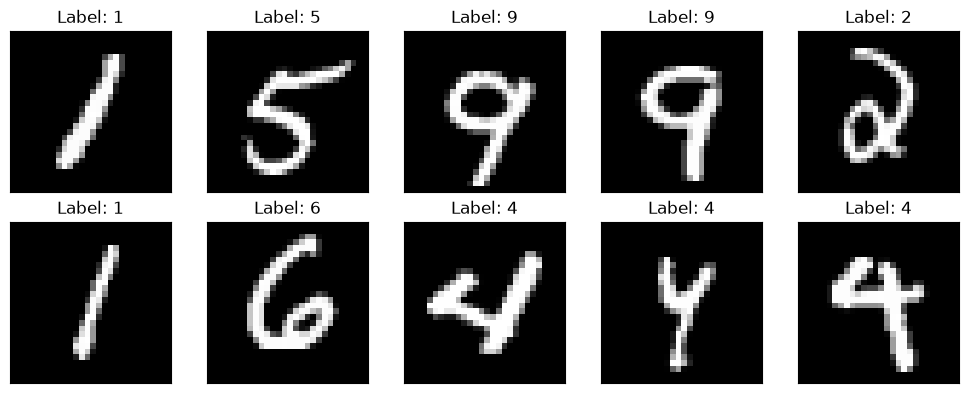

In [10]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Define a transformation to normalize the data and convert it to tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Mean and std dev of MNIST dataset
])

# Download and load the training data
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64, # How many images to process at once
    shuffle=True
)

# Download and load the test data
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=1000, # Typically larger batch size for testing
    shuffle=False
)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

# Let's visualize a few images from the training set
images, labels = next(iter(train_loader))
fig = plt.figure(figsize=(10, 4))
for i in range(10):
    ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
    ax.imshow(images[i].numpy().squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
plt.tight_layout()
plt.show()

## Capstone Challenge: MNIST Digit Classifier

Now, let's apply what we've learned to build a classifier for the famous MNIST dataset, which consists of handwritten digits.

### 1. Define the Neural Network Architecture
Your task is to complete the `DigitRecognizer` class below. Remember the MNIST images are 28x28 pixels.
*   Add at least one hidden layer.
*   The final output layer should have 10 units (one for each digit 0-9).

In [11]:
class DigitRecognizer(nn.Module):
    def __init__(self):
        super(DigitRecognizer, self).__init__()
        # MNIST images are 28x28 = 784 pixels.
        # Add your layers here.
        # Example: self.fc1 = nn.Linear(784, 128)
        # Remember to add at least one hidden layer and an output layer of size 10.
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10) # Output layer with 10 classes (digits 0-9)

    def forward(self, x):
        # Flatten the input image: (batch_size, 1, 28, 28) -> (batch_size, 784)
        x = x.view(x.shape[0], -1)

        # Apply your layers and activation functions
        # Example: x = F.relu(self.fc1(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # Output layer, no activation here for CrossEntropyLoss
        return x

# Instantiate the model
model = DigitRecognizer()
print("DigitRecognizer architecture:\n", model)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"\nModel moved to: {device}")

DigitRecognizer architecture:
 DigitRecognizer(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

Model moved to: cpu


### 2. Define Loss Function and Optimizer
Complete the code below to instantiate a loss function and an optimizer.
*   For multi-class classification like MNIST, `nn.CrossEntropyLoss()` is a common and effective choice.
*   For the optimizer, you can choose `optim.SGD` (Stochastic Gradient Descent) or `optim.Adam`. Remember to pass `model.parameters()` to the optimizer so it knows which parameters to update.

In [12]:
# Instantiate the loss function and optimizer
# criterion = ...
# optimizer = ...

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # Example with Adam optimizer and learning rate

### 3. Implement the Training Loop
Now, put it all together! Complete the training loop below by implementing the four steps we discussed:
1.  Forward Pass
2.  Calculate Loss
3.  Backward Pass
4.  Optimizer Step & Zero Grad

In [13]:
num_epochs = 5 # You can increase this for better accuracy

for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # 1. Forward Pass: Get predictions
        # outputs = ...
        outputs = model(images)

        # 2. Calculate Loss: Compute how wrong the predictions are
        # loss = ...
        loss = criterion(outputs, labels)

        # 3. Backward Pass: Compute gradients
        # ...
        loss.backward()

        # 4. Optimizer Step & Zero Grad: Update weights and clear gradients
        # ...
        # ...
        optimizer.step()
        optimizer.zero_grad()

        running_loss += loss.item()
        if (i + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss / 100:.4f}")
            running_loss = 0.0

print("\nFinished Training!")

Epoch [1/5], Step [100/938], Loss: 0.7388
Epoch [1/5], Step [200/938], Loss: 0.3245
Epoch [1/5], Step [300/938], Loss: 0.2754
Epoch [1/5], Step [400/938], Loss: 0.2258
Epoch [1/5], Step [500/938], Loss: 0.2089
Epoch [1/5], Step [600/938], Loss: 0.1807
Epoch [1/5], Step [700/938], Loss: 0.1747
Epoch [1/5], Step [800/938], Loss: 0.1613
Epoch [1/5], Step [900/938], Loss: 0.1534
Epoch [2/5], Step [100/938], Loss: 0.1202
Epoch [2/5], Step [200/938], Loss: 0.1396
Epoch [2/5], Step [300/938], Loss: 0.1148
Epoch [2/5], Step [400/938], Loss: 0.1315
Epoch [2/5], Step [500/938], Loss: 0.1012
Epoch [2/5], Step [600/938], Loss: 0.1100
Epoch [2/5], Step [700/938], Loss: 0.0960
Epoch [2/5], Step [800/938], Loss: 0.1042
Epoch [2/5], Step [900/938], Loss: 0.1117
Epoch [3/5], Step [100/938], Loss: 0.0783
Epoch [3/5], Step [200/938], Loss: 0.0883
Epoch [3/5], Step [300/938], Loss: 0.0797
Epoch [3/5], Step [400/938], Loss: 0.0715
Epoch [3/5], Step [500/938], Loss: 0.0881
Epoch [3/5], Step [600/938], Loss:

### 4. Evaluate the Model
Let's see how well our trained model performs on the test set.

Accuracy of the model on the 10000 test images: 97.37%


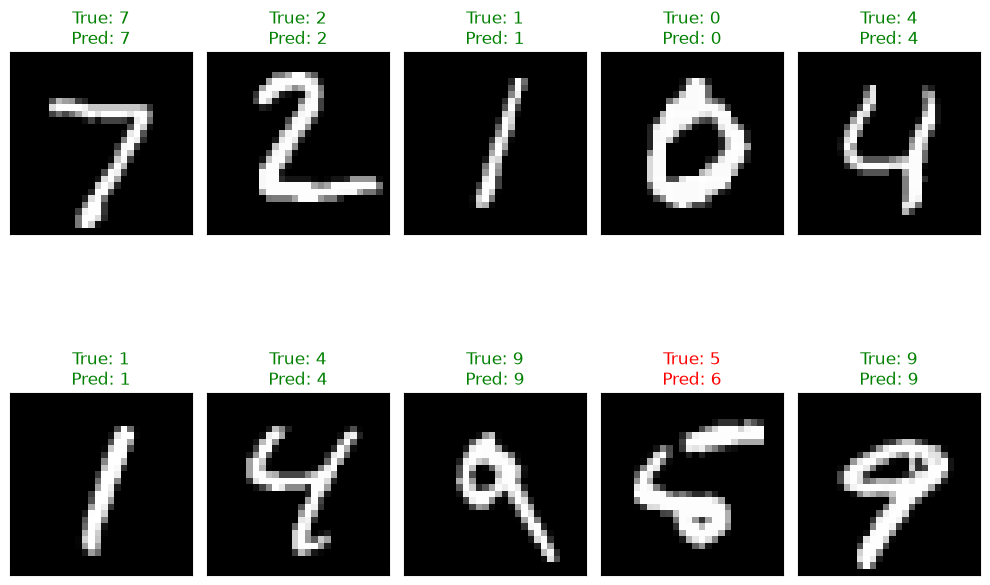

In [14]:
model.eval() # Set the model to evaluation mode (turns off dropout, batchnorm updates, etc.)
with torch.no_grad(): # Disable gradient calculation during inference
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) # Get the class with the highest probability
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Accuracy of the model on the 10000 test images: {100 * correct / total:.2f}%")

# Visualize some predictions
fig = plt.figure(figsize=(10, 8))
# Get a batch from the test loader
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images[:10]) # Take first 10 for visualization
_, predicted = torch.max(outputs.data, 1)

for i in range(10):
    ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
    ax.imshow(images[i].cpu().numpy().squeeze(), cmap='gray')
    ax.set_title(f"True: {labels[i].item()}\nPred: {predicted[i].item()}",
                 color=("green" if predicted[i] == labels[i] else "red"))
plt.tight_layout()
plt.show()

# What is machine learning?

Machine learning is, fundamentally, taking some initial information and predicting what will happen before it actually happens.

You could take the medical history of a patient and predict whether they'll have cancer. You could take the application of a JClinic student and predict whether they'll get into the camp. If you had enough data, you could've predicted 67.

You'll hear a lot about a neural network and convolutions, weights, biases, etc., but a neural network is just an equation. That's it. It's an equation that takes some input data and, again, makes an output as a prediction.

Our job is to figure out what the equation is.

## Input Data

First, we're going to predict patient